## Data Science I project
## Coupon Acceptance: Behavioral and Contextual Influences-Yu-Ting Chu

### 1. Introduction

#### Objective
This project aims to understand the behavioral and contextual factors influencing a customer's decision to accept a discount coupon while inside a vehicle. This kind of analysis has potential applications in location-based marketing, personalized advertising, and understanding user behavior for mobile recommendation systems.

#### Dataset Introduction
The data is **In-Vehicle Coupon Recommendation** dataset from the UCI Machine Learning Repository:  🔗 [Dataset Link](https://archive.ics.uci.edu/dataset/603/in+vehicle+coupon+recommendation)

The dataset contains simulated survey data about passengers who received various types of coupons during a trip and whether they accepted the offer. It includes demographic features (e.g., age, gender), temporal and situational context (e.g., time, weather, destination), and psychological/behavioral indicators (e.g., marital status, education, decision-making). And Y means if the person accept the coupon or not.

This rich combination of demographic, situational, and psychological factors provides an opportunity to analyze and predict coupon acceptance behavior in real-world scenarios. The dataset’s structured format and diversity of features make it well-suited for supervised learning and statistical analysis, aiming to understand and model consumer decision-making during travel.

#### Problem Statement
This project aims to solve the following problem:
> "Given user demographics (e.g., age, gender, income) and trip context (e.g., travel purpose, weather conditions, time of day), can we accurately predict whether a person will accept the offered coupon?"

The task is formulated as a **binary classification** problem, enabling the application of supervised learning techniques such as logistic regression, decision trees, random forests, and gradient boosting. Multiple models will be trained, tuned, and evaluated to determine which method delivers the highest predictive performance for this dataset.

In addition to predictive modeling, **hypothesis testing** will be performed to statistically assess the influence of specific behavioral and contextual factors on coupon acceptance rates. For instance, the analysis may examine whether weather significantly impacts acceptance likelihood or whether certain age groups respond more positively to particular offers.

By integrating predictive modeling with statistical inference, the analysis aims to both forecast user behavior and uncover actionable insights into the psychological and situational drivers of decision-making. The findings have the potential to guide businesses in developing more targeted and effective coupon marketing strategies, delivering the right offer to the right audience at the optimal time and reducing wasted promotions. 

### 2. Data Preprocessing

In [75]:
# import package
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
# Load dataset
url = "https://archive.ics.uci.edu/static/public/603/in+vehicle+coupon+recommendation.zip"
df = pd.read_csv(url)

In [77]:
df

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12679,Home,Partner,Rainy,55,6PM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,1
12680,Work,Alone,Rainy,55,7AM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,0,1,1
12681,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,0
12682,Work,Alone,Snowy,30,7AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,1,0,1,0


In [78]:
print(df.shape)
df.head()

(12684, 26)


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [79]:
# Check for missing data
missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing > 0])

Missing values per column:
 car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
dtype: int64


In [80]:
print(df[df.CoffeeHouse.isnull()])

           destination  passanger weather  temperature  time  \
495    No Urgent Place      Alone   Sunny           55   2PM   
496    No Urgent Place  Friend(s)   Sunny           80  10AM   
497    No Urgent Place  Friend(s)   Sunny           80  10AM   
498    No Urgent Place  Friend(s)   Sunny           80   2PM   
499    No Urgent Place  Friend(s)   Sunny           80   2PM   
...                ...        ...     ...          ...   ...   
12409             Home      Alone   Sunny           80   6PM   
12410             Work      Alone   Rainy           55   7AM   
12411             Work      Alone   Snowy           30   7AM   
12412             Work      Alone   Snowy           30   7AM   
12413             Work      Alone   Sunny           80   7AM   

                      coupon expiration  gender age      maritalStatus  ...  \
495          Restaurant(<20)         1d    Male  26  Unmarried partner  ...   
496             Coffee House         2h    Male  26  Unmarried partner  .

In [81]:
# drop unnecessary columns
df = df.drop(["car","toCoupon_GEQ5min","toCoupon_GEQ15min","toCoupon_GEQ25min","direction_same","direction_opp"], axis=1)

In [82]:
print(df.shape)
df

(12684, 20)


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,education,occupation,income,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,never,never,NaN,4~8,1~3,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,never,never,NaN,4~8,1~3,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,never,never,NaN,4~8,1~3,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,never,never,NaN,4~8,1~3,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,never,never,NaN,4~8,1~3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12679,Home,Partner,Rainy,55,6PM,Carry out & Take away,1d,Male,26,Single,0,Bachelors degree,Sales & Related,$75000 - $87499,never,never,1~3,4~8,1~3,1
12680,Work,Alone,Rainy,55,7AM,Carry out & Take away,1d,Male,26,Single,0,Bachelors degree,Sales & Related,$75000 - $87499,never,never,1~3,4~8,1~3,1
12681,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,26,Single,0,Bachelors degree,Sales & Related,$75000 - $87499,never,never,1~3,4~8,1~3,0
12682,Work,Alone,Snowy,30,7AM,Bar,1d,Male,26,Single,0,Bachelors degree,Sales & Related,$75000 - $87499,never,never,1~3,4~8,1~3,0


In [83]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

label_enc_cols = ['gender', 'age', 'maritalStatus', 'education', 'occupation',
                  'income', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20',
                  'Restaurant20To50', 'destination', 'passanger',
                  'weather', 'temperature', 'time', 'coupon']

df_encoded = df.copy()

for col in label_enc_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Final dataset shape
df_encoded.shape

(12684, 20)

### 3. Exploratory Data Analysis (EDA)

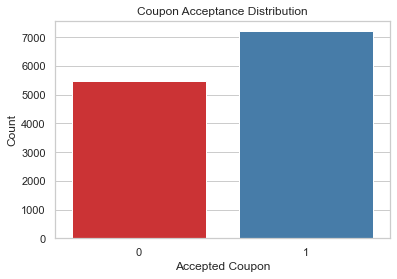

In [94]:
# Distribution of coupon acceptance
sns.countplot(x='Y', data=df, palette='Set1')
plt.title("Coupon Acceptance Distribution")
plt.xlabel("Accepted Coupon")
plt.ylabel("Count")
plt.show()

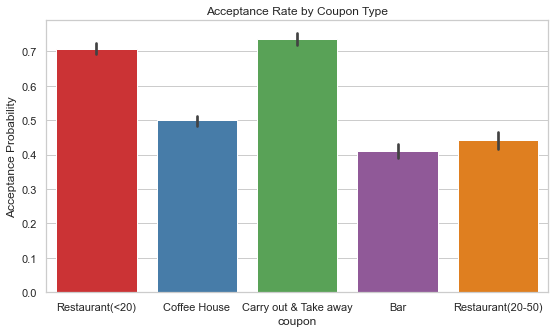

In [112]:
# Acceptance by coupon type
plt.figure(figsize=(9,5))
sns.barplot(x='coupon', y='Y', data=df, palette='Set1')
plt.title("Acceptance Rate by Coupon Type")
plt.ylabel("Acceptance Probability")
plt.show()

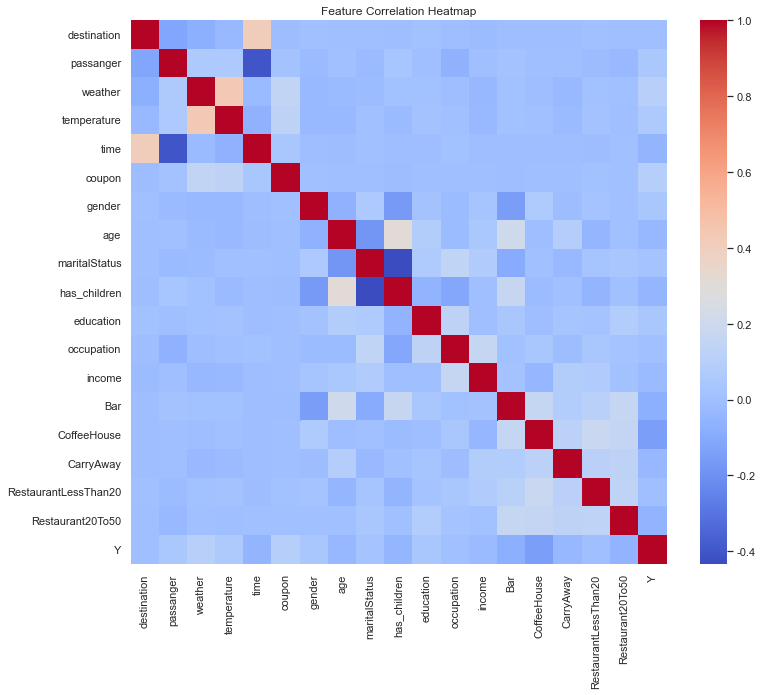

In [86]:
# Heatmap of correlations
plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

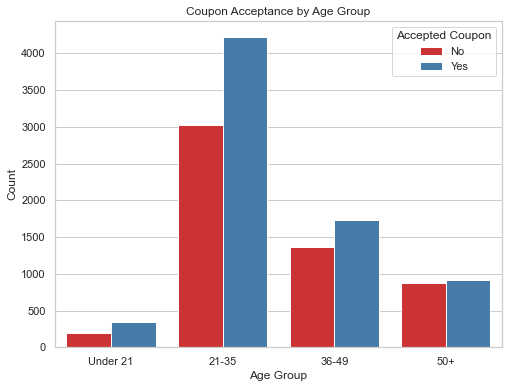

In [87]:
#Feature extraction/engineering

#Age
def age_group(age):
    if age in ['below21']:
        return 'Under 21'
    elif age in ['21', '26', '31']:
        return '21-35'
    elif age in ['36', '41','46']:
        return '36-49'
    elif age == '50plus':
        return '50+'
    else:
        return 'Other'

df['age_group'] = df['age'].apply(age_group)
age_order = ['Under 21', '21-35', '36-49', '50+']

df['age_group'] = pd.Categorical(df['age_group'], categories=age_order, ordered=True)

plt.figure(figsize=(8,6))
sns.countplot(x='age_group',hue='Y', data=df, palette='Set1', order=age_order)
plt.title('Coupon Acceptance by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Accepted Coupon', labels=['No', 'Yes'])
plt.show()

Coupon acceptance varies notably across age groups. The 21–35 age group shows the highest acceptance rate, indicating strong responsiveness to coupon offers. Acceptance also remains relatively high among those aged 36–49, while the 50+ group shows a more balanced response. The Under 21 group has the lowest engagement overall. These trends suggest that younger to middle-aged adults are more likely to accept coupons, which can inform targeted marketing strategies.

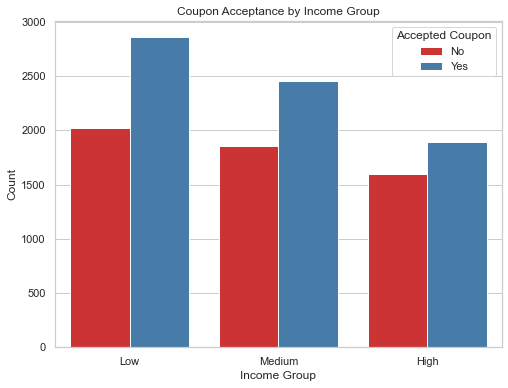

In [122]:
#Income
low_income = ['Less than $12500', '$12500 - $24999', '$25000 - $37499']
medium_income = ['$37500 - $49999', '$50000 - $62499', '$62500 - $74999']
high_income = ['$75000 - $87499', '$87500 - $99999', '$100000 or More']

def income_group(income):
    if income in low_income:
        return 'Low'
    elif income in medium_income:
        return 'Medium'
    elif income in high_income:
        return 'High'
    else:
        return 'Unknown'

df['income_group'] = df['income'].apply(income_group)
income_order = ['Low', 'Medium', 'High']

df['income_group'] = pd.Categorical(df['income_group'], categories=income_order, ordered=True)

plt.figure(figsize=(8,6))
sns.countplot(x='income_group', hue='Y', data=df, palette='Set1', order=income_order)
plt.title('Coupon Acceptance by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Count')
plt.legend(title='Accepted Coupon', labels=['No', 'Yes'])
plt.show()

The graph shows that coupon acceptance is consistently higher than rejection across all income levels, especially among low and medium-income groups. This suggests that coupons are more appealing to lower-income consumers, making them ideal targets for promotional campaigns.

In [89]:
print(df['income'].unique())

['$37500 - $49999' '$62500 - $74999' '$12500 - $24999' '$75000 - $87499'
 '$50000 - $62499' '$25000 - $37499' '$100000 or More' '$87500 - $99999'
 'Less than $12500']


In [90]:
#Time
time_map = {'7AM': 7, '10AM': 10, '2PM': 14, '6PM': 18, '10PM': 22}
df['time_num'] = df['time'].map(time_map)

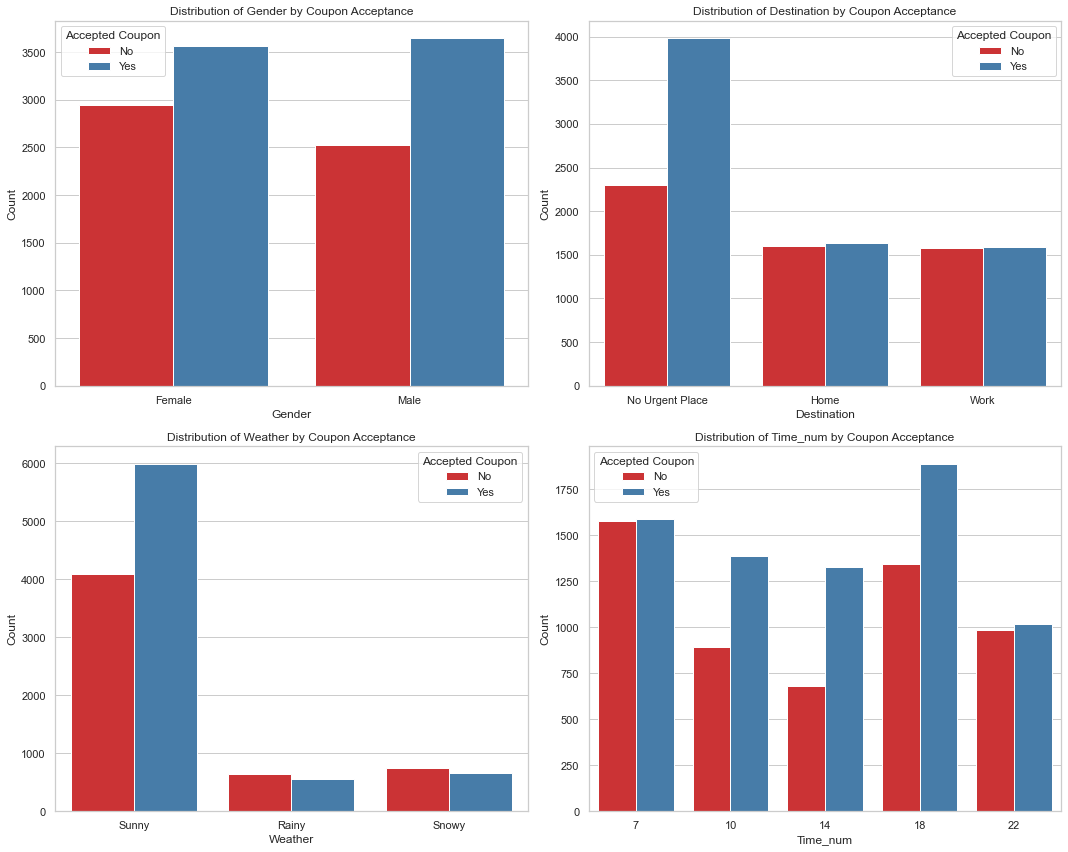

In [91]:
#Distributions of some important variables with coupon acceptance
sns.set(style="whitegrid")
variables = ['gender', 'destination', 'weather', 'time_num']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, var in enumerate(variables):
    sns.countplot(x=var, hue='Y', data=df, ax=axes[i], palette='Set1')
    axes[i].set_title(f'Distribution of {var.capitalize()} by Coupon Acceptance')
    axes[i].set_xlabel(var.capitalize())
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Accepted Coupon', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

The graph reveals clear patterns in coupon acceptance behavior across multiple factors. Females show a higher acceptance rate than males, suggesting gender may influence responsiveness to promotions. Sunny weather correlates with the highest acceptance, while rainy or cloudy conditions see lower engagement, indicating that mood or mobility tied to weather may affect decision-making.

Acceptance is also more common when individuals are heading to non-urgent destinations, implying that relaxed or discretionary outings may encourage promotional uptake. Additionally, acceptance peaks around 18:00, possibly aligning with post-work hours when consumers are more receptive to offers.

These trends highlight that coupon acceptance is context-sensitive, influenced by personal, environmental, and temporal factors. Businesses can leverage these insights to optimize marketing strategies, such as timing promotions for evening hours, targeting female consumers, or aligning offers with favorable weather conditions. Further analysis could refine these findings and support more personalized campaign designs.

### 4. Hypothesis Testing
#### Coupon Acceptance Rate Differs by Weather

- **Null Hypothesis (H₀):** Coupon acceptance rate is independent of weather conditions.  
- **Alternative Hypothesis (H₁):** Coupon acceptance rate depends on weather conditions (i.e., acceptance rate differs by weather).

Explanation of Test Statistic Choice and Relevance:
The test statistic used is the Chi-square statistic from the Chi-square test of independence. This test is appropriate because both variables, weather (categorical) and coupon acceptance (binary/categorical), are categorical variables.

The Chi-square test measures if there is a significant association between two categorical variables by comparing observed frequencies to expected frequencies under the null hypothesis. If the variables are independent, observed counts should be close to expected counts calculated from marginal totals.

In [92]:
# Contingency table
contingency = pd.crosstab(df['weather'], df['Y'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.3f}, p-value: {p:.3f}")

if p < 0.05:
    print("Reject null hypothesis: Coupon acceptance depends on weather.")
else:
    print("Fail to reject null hypothesis: No dependence on weather.")

Chi-square statistic: 138.525, p-value: 0.000
Reject null hypothesis: Coupon acceptance depends on weather.


#### Conclusion

The Chi-square test yielded a statistic of 138.525 with a p-value < 0.001, leading us to reject the null hypothesis. This indicates a significant association between weather conditions and coupon acceptance rates — in other words, coupon acceptance depends on the weather.

### 5. Classification Model

A **Random Forest Classifier** was used to predict coupon acceptance (binary target Y) based on selected features. Random Forest is an ensemble method combining multiple decision trees to improve prediction accuracy and reduce overfitting.

Data Splitting Strategy: The dataset was split into a training set (80%) and a test set (20%) using train_test_split with random_state=42 for reproducibility. This approach ensures the model trains on a large portion of the data while reserving unseen data for fair evaluation of performance and generalization.

#### Random Forest Model Explanation

A Random Forest consists of \( T \) decision trees $  \{h_t(x)\}_{t=1}^T $. For an input vector \( x \), each tree outputs a predicted class label \( h_t(x) \). The final prediction is determined by majority voting:

$$\hat{y} = \arg\max_{c \in \{0,1\}} \sum_{t=1}^T \mathbf{1}\left(h_t(x) = c\right)$$

where $ \mathbf{1} $ is the indicator function.

**Justification:**

- Handles both categorical and continuous variables effectively (after encoding).
- Robust to noise and overfitting due to averaging multiple trees.
- Provides good accuracy for classification tasks without extensive parameter tuning.
- Suitable baseline for tabular data.


#### Hyperparameter Selection
Default hyperparameters from scikit-learn’s RandomForestClassifier were used. These include number of trees (n_estimators=100) and unlimited tree depth by default.

Hyperparameters such as n_estimators, max_depth, and min_samples_split could be optimized using Grid Search or Random Search with cross-validation to improve performance.

In [117]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

In [118]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

label_enc_cols = ['gender', 'age', 'maritalStatus', 'education', 'occupation',
                  'income', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20',
                  'Restaurant20To50', 'destination', 'passanger',
                  'weather', 'temperature', 'time', 'coupon','age_group', 'income_group', 'time_num']

df_encoded = df.copy()

for col in label_enc_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Final dataset shape
df_encoded.shape

(12684, 23)

In [119]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Select features and target
X = df_encoded[['age_group','income_group','gender', 'destination', 'weather', 'time_num']]
y = df_encoded['Y']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model: Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5778478517934569
              precision    recall  f1-score   support

           0       0.55      0.27      0.36      1128
           1       0.59      0.82      0.68      1409

    accuracy                           0.58      2537
   macro avg       0.57      0.55      0.52      2537
weighted avg       0.57      0.58      0.54      2537



**Accuracy (58%)** indicates moderate overall prediction correctness.

**Recall for Class 1 (82%)** shows good identification of coupon accepters.

**Recall for Class 0 (27%)** is low, indicating many non-accepters are missed.

**F1-scores** represent the balance between precision and recall per class.

This performance suggests bias towards predicting acceptance (Class 1). Possible improvements include hyperparameter tuning, class balancing techniques (e.g., SMOTE, class weights), and additional feature engineering.

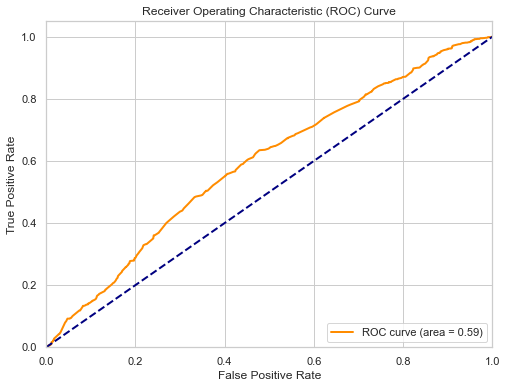

In [120]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Assuming binary classification with classes 0 and 1
# Predict probabilities for the positive class
y_scores = model.predict_proba(X_test)[:, 1]

# Compute ROC curve and ROC area
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange',
         lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Area Under the Curve (AUC = 0.59): Measures overall model discrimination ability. AUC of 0.5 means random guessing, while 1.0 means perfect classification. Your model’s AUC of 0.59 suggests performance is only slightly better than random guessing.

Interpretation:

1. The model shows limited ability to distinguish between the classes.

2. There is some predictive power, but it could be improved.

3. Adjusting model parameters or using more features might boost performance.

### 6. Conclusion

#### Hypothesis Testing
The Chi-square test revealed a significant relationship between weather and coupon acceptance, with a test statistic of 138.525 and a p-value below 0.001. This result leads us to reject the null hypothesis, confirming that coupon acceptance rates vary depending on weather conditions. The test compares observed and expected frequencies, and the large discrepancy indicates that weather influences consumer behavior. This insight suggests that marketing strategies could benefit from weather-based targeting. Businesses may improve campaign effectiveness by aligning promotions with specific weather patterns that correlate with higher acceptance rates. Further analysis could identify which conditions drive the strongest responses.

#### Classification model
The model currently achieves a moderate accuracy of 58%, indicating that just over half of its predictions are correct. However, its performance is biased toward predicting coupon acceptance (Class 1). This is evident from the high recall for Class 1 (82%), meaning it successfully identifies most coupon accepters. In contrast, the low recall for Class 0 (27%) reveals that it frequently fails to recognize non-accepters.

The F1-scores, which balance precision and recall, further highlight the disparity in performance between the two classes. Additionally, the Area Under the Curve (AUC) score of 0.59 suggests that the model's ability to distinguish between accepters and non-accepters is only slightly better than random guessing.

Overall, while the model shows some predictive capability, it lacks reliability and discriminative power. To improve its performance, consider strategies such as hyperparameter tuning, class balancing techniques (like SMOTE or adjusting class weights), and enhanced feature engineering to provide the model with more informative inputs.


Together, these findings highlight the importance of contextual factors like weather in shaping consumer decisions and the need to enhance model performance through techniques such as class balancing, hyperparameter tuning, and feature engineering. By combining behavioral insights with improved predictive tools, businesses can better target and personalize their promotional efforts.

### 7.Citation

#### Data
In-Vehicle Coupon Recommendation dataset: https://archive.ics.uci.edu/dataset/603/in+vehicle+coupon+recommendation

#### Python Library
pandas, numpy, matplotlib.pyplot, seaborn, sklearn